count    10000.000000
mean       377.572120
std         67.287038
min         94.535000
25%        333.180000
50%        380.842500
75%        427.177500
max        580.850000
Name: coach_price, dtype: float64
Average Coach Price: 377.57212000000004


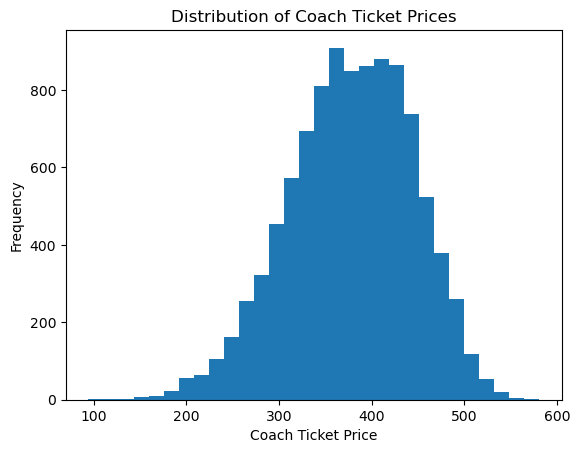

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
flight = pd.read_csv("C:/Users/USER/Downloads/R & Python/flight_data.csv")

# Random sample using student ID
flight_sample = flight.sample(n=10000, random_state=66)

## Q.1: What do coach ticket prices look like? What are the high and low values? What would be considered the average? Does $500 seem like a good price for a coach ticket?”
#Summary statistics
print(flight_sample['coach_price'].describe())

# Mean
mean_price = flight_sample['coach_price'].mean()
print("Average Coach Price:", mean_price)

# Histogram
plt.hist(flight_sample['coach_price'], bins=30)
plt.xlabel("Coach Ticket Price")
plt.ylabel("Frequency")
plt.title("Distribution of Coach Ticket Prices")
plt.show()

In [4]:
##Q2: What are the coach prices for flights that are 8 hours long? Does a $500 ticket seem more reasonable for these flights?
# 8-hour flights
flight_8hr = flight_sample[flight_sample['hours'] == 8]

# Summary statistics
print(flight_8hr['coach_price'].describe())

count    212.000000
mean     438.763821
std       57.962725
min      242.600000
25%      405.296250
50%      446.252500
75%      478.943750
max      561.750000
Name: coach_price, dtype: float64


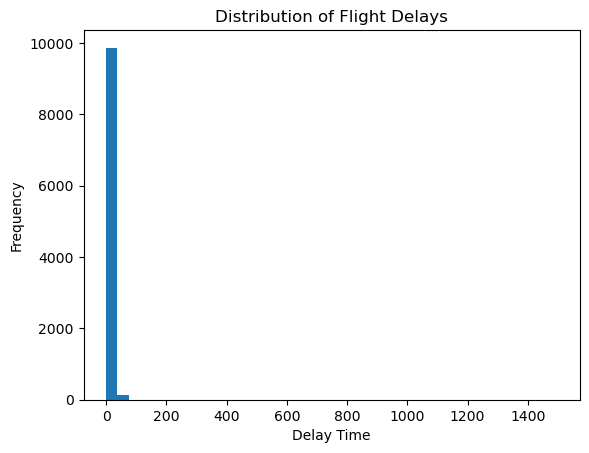

count    10000.000000
mean        13.139800
std         39.697635
min          0.000000
25%          9.000000
50%         10.000000
75%         13.000000
max       1497.000000
Name: delay, dtype: float64


In [5]:
##Q3: What does the distribution of flight delays look like? Are there any outliers?

import matplotlib.pyplot as plt

# Histogram of delays
plt.hist(flight_sample['delay'], bins=40)
plt.xlabel("Delay Time")
plt.ylabel("Frequency")
plt.title("Distribution of Flight Delays")
plt.show()

# Summary statistics
print(flight_sample['delay'].describe())

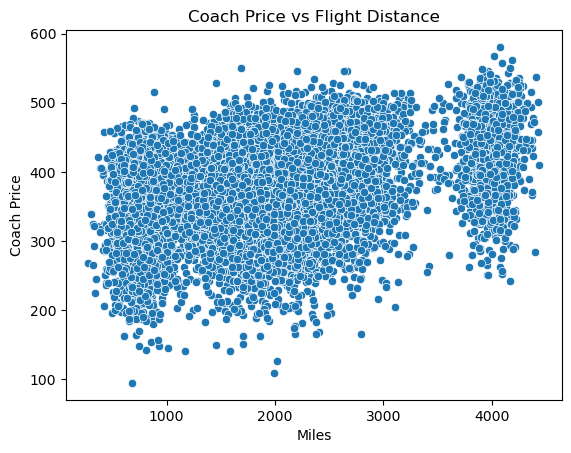

                miles  coach_price
miles        1.000000     0.372265
coach_price  0.372265     1.000000


In [6]:
##Q4: How are coach ticket prices related to flight distance (miles)?

import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot
sns.scatterplot(
    x='miles',
    y='coach_price',
    data=flight_sample
)

plt.xlabel("Miles")
plt.ylabel("Coach Price")
plt.title("Coach Price vs Flight Distance")
plt.show()

# Correlation
print(flight_sample[['miles','coach_price']].corr())

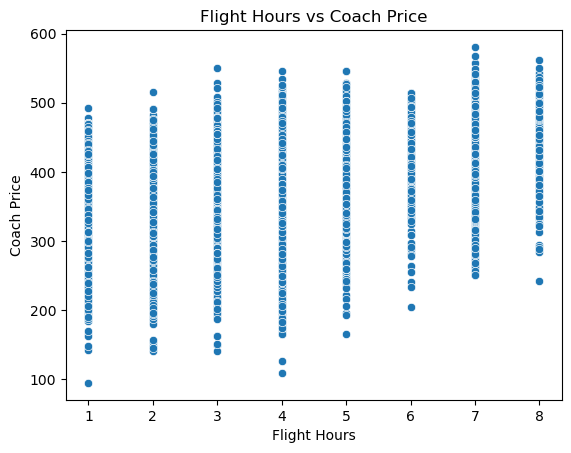

                hours  coach_price
hours        1.000000     0.366395
coach_price  0.366395     1.000000


In [7]:
##Q5: How are flight hours related to coach ticket prices?

import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot
sns.scatterplot(
    x='hours',
    y='coach_price',
    data=flight_sample
)

plt.xlabel("Flight Hours")
plt.ylabel("Coach Price")
plt.title("Flight Hours vs Coach Price")
plt.show()

# Correlation
print(flight_sample[['hours','coach_price']].corr())

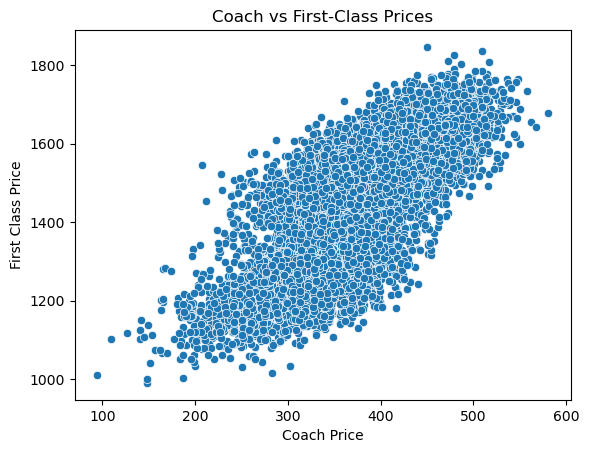

                  coach_price  firstclass_price
coach_price          1.000000          0.757325
firstclass_price     0.757325          1.000000


In [8]:
##Q6: How are coach ticket prices related to first-class ticket prices?
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot
sns.scatterplot(
    x='coach_price',
    y='firstclass_price',
    data=flight_sample
)

plt.xlabel("Coach Price")
plt.ylabel("First Class Price")
plt.title("Coach vs First-Class Prices")
plt.show()

# Correlation
print(flight_sample[['coach_price',
                     'firstclass_price']].corr())


In [9]:
##Q7: How do in-flight features affect coach ticket prices?
# Average coach prices by features

print(flight_sample.groupby(
    'inflight_meal')['coach_price'].mean())

print(flight_sample.groupby(
    'inflight_entertainment')['coach_price'].mean())

print(flight_sample.groupby(
    'inflight_wifi')['coach_price'].mean())

inflight_meal
No     371.829576
Yes    391.282637
Name: coach_price, dtype: float64
inflight_entertainment
No     322.052406
Yes    391.209997
Name: coach_price, dtype: float64
inflight_wifi
No     314.918785
Yes    384.310008
Name: coach_price, dtype: float64


         coach_price  firstclass_price
weekend                               
No        323.047448       1258.846526
Yes       406.088374       1559.762531


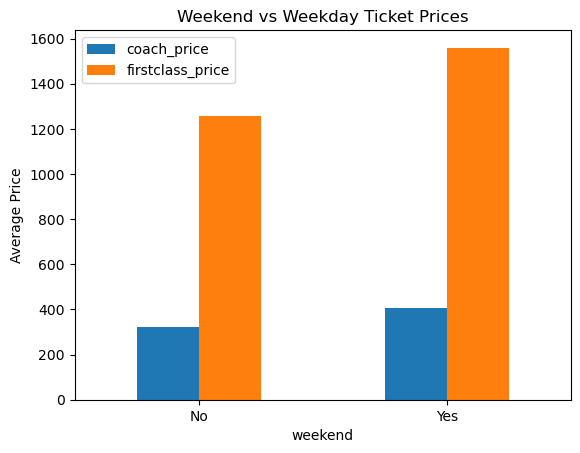

In [10]:
##Q8: How do weekend flights compare to weekday flights in terms of ticket prices?
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Average ticket prices
weekend_price = flight_sample.groupby('weekend')[
    ['coach_price', 'firstclass_price']
].mean()

print(weekend_price)

# Bar plot
weekend_price.plot(kind='bar')

plt.title("Weekend vs Weekday Ticket Prices")
plt.ylabel("Average Price")
plt.xticks(rotation=0)
plt.show()

redeye
No     380.715426
Yes    316.435143
Name: coach_price, dtype: float64


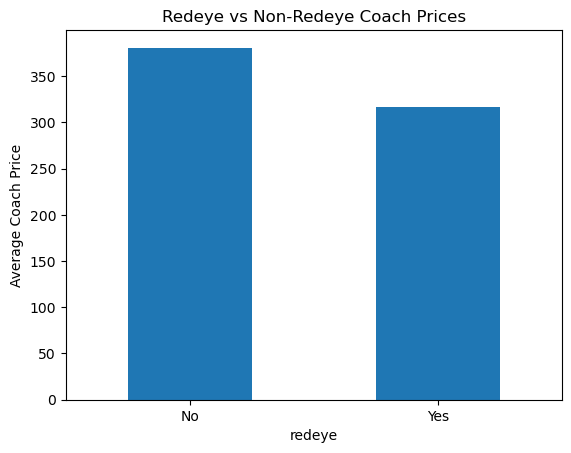

In [11]:
##Q9: How do redeye flights compare to non-redeye flights in terms of coach ticket prices?
import seaborn as sns
import matplotlib.pyplot as plt

# Average coach prices
redeye_price = flight_sample.groupby('redeye')[
    'coach_price'
].mean()

print(redeye_price)

# Bar plot
redeye_price.plot(kind='bar')

plt.title("Redeye vs Non-Redeye Coach Prices")
plt.ylabel("Average Coach Price")
plt.xticks(rotation=0)
plt.show()

In [15]:
##Q10: Perform the analysis for appropriate variables
#(1)Summary
flight_sample.describe()

,miles,passengers,delay,coach_price,firstclass_price,hours
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2011.737400,207.653500,13.139800,377.572120,1456.427975,3.635600
std,955.070753,12.714905,39.697635,67.287038,162.780237,1.760092
min,279.000000,143.000000,0.000000,94.535000,990.010000,1.000000
25%,1320.000000,204.000000,9.000000,333.180000,1304.675000,2.000000
50%,1982.500000,209.000000,10.000000,380.842500,1503.420000,4.000000
75%,2475.000000,215.000000,13.000000,427.177500,1584.047500,4.000000
max,4438.000000,236.000000,1497.000000,580.850000,1846.780000,8.000000


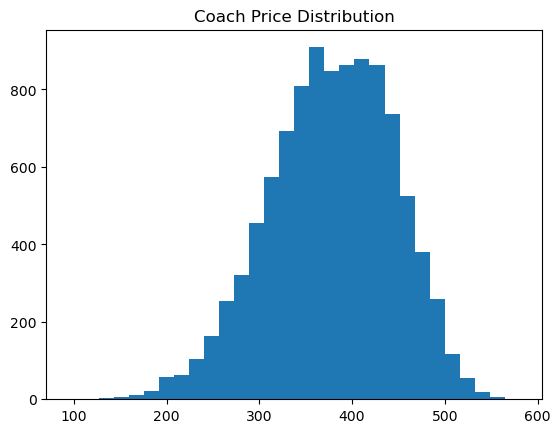

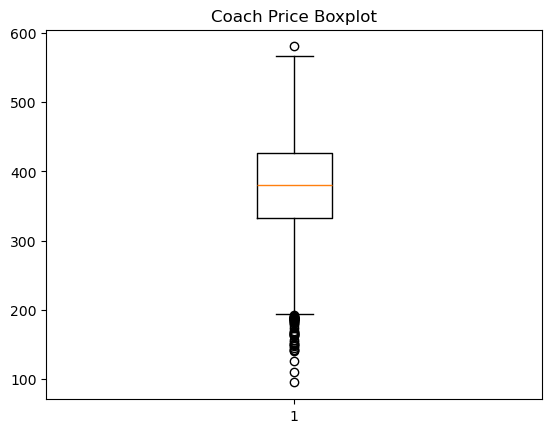

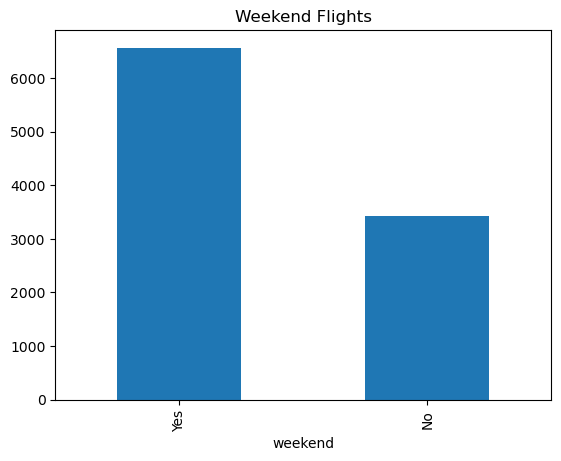

In [12]:
#10(2) Visualization
import matplotlib.pyplot as plt

# Histogram
plt.hist(flight_sample['coach_price'], bins=30)
plt.title("Coach Price Distribution")
plt.show()

# Boxplot
plt.boxplot(flight_sample['coach_price'])
plt.title("Coach Price Boxplot")
plt.show()

# Bar chart
flight_sample['weekend'].value_counts().plot(kind='bar')
plt.title("Weekend Flights")
plt.show()

In [13]:
##10(c) Hypothesis Testing (t-test)
from scipy import stats

weekend_yes = flight_sample[
    flight_sample['weekend']=="Yes"
]['coach_price']

weekend_no = flight_sample[
    flight_sample['weekend']=="No"
]['coach_price']

stats.ttest_ind(weekend_yes, weekend_no)

TtestResult(statistic=np.float64(72.3196681400005), pvalue=np.float64(0.0), df=np.float64(9998.0))

In [14]:
##10(d) Correlation Analysis
flight_sample[
 ['coach_price',
  'miles',
  'hours',
  'delay']
].corr()

,coach_price,miles,hours,delay
coach_price,1.000000,0.372265,0.366395,0.018023
miles,0.372265,1.000000,0.985873,0.005649
hours,0.366395,0.985873,1.000000,0.008739
delay,0.018023,0.005649,0.008739,1.000000


In [15]:
##10(e) Regression Analysis
from sklearn.linear_model import LinearRegression

X = flight_sample[
 ['miles','hours','delay']
]

y = flight_sample['coach_price']

model = LinearRegression()
model.fit(X,y)

print(model.coef_)


[ 0.02785972 -0.90216435  0.02711225]


In [16]:
##10(f) Logistic Regression
from sklearn.linear_model import LogisticRegression

flight_sample['redeye_binary'] = (
    flight_sample['redeye']=="Yes"
).astype(int)

X = flight_sample[
 ['hours','coach_price']
]

y = flight_sample['redeye_binary']

log_model = LogisticRegression()
log_model.fit(X,y)

print(log_model.score(X,y))

0.9508


In [17]:
from sklearn.linear_model import LinearRegression

X = flight_sample[
 ['miles',
  'hours',
  'delay']
]

y = flight_sample['coach_price']

model = LinearRegression()

model.fit(X, y)

print(model.coef_)
print(model.intercept_)

[ 0.02785972 -0.90216435  0.02711225]
324.44933798732814
